# Weather Prediction using Machine Learning

**Student:** Mahmoud Saad Elaidi  
**ID:** 224101559

---

## Project Overview
This notebook predicts the daily weather condition (drizzle, fog, rain, snow, sun) from numeric weather measurements using **four classification algorithms**:

1. Random Forest  
2. K-Nearest Neighbors (KNN)  
3. Support Vector Machine (SVM)  
4. XGBoost

The four models are compared using **Accuracy, Precision, Recall, F1-score, and Confusion Matrix**.

## Dataset
**Seattle Weather Dataset** — 1461 daily records from 2012–2015.  
Source: [Vega-datasets / Kaggle](https://www.kaggle.com/datasets/ananthr1/weather-prediction)

Columns: `date`, `precipitation`, `temp_max`, `temp_min`, `wind`, `weather` (target).

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
print('Libraries imported successfully.')

Libraries imported successfully.


## 2. Load the Dataset

In [2]:
df = pd.read_csv('seattle-weather.csv')
print('Shape:', df.shape)
df.head()

Shape: (1461, 6)


,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1461 non-null   str    
 1   precipitation  1461 non-null   float64
 2   temp_max       1461 non-null   float64
 3   temp_min       1461 non-null   float64
 4   wind           1461 non-null   float64
 5   weather        1461 non-null   str    
dtypes: float64(4), str(2)
memory usage: 68.6 KB


In [4]:
# Statistical summary
df.describe()

,precipitation,temp_max,temp_min,wind
count,1461.000000,1461.000000,1461.000000,1461.000000
mean,3.029432,16.439083,8.234771,3.241136
std,6.680194,7.349758,5.023004,1.437825
min,0.000000,-1.600000,-7.100000,0.400000
25%,0.000000,10.600000,4.400000,2.200000
50%,0.000000,15.600000,8.300000,3.000000
75%,2.800000,22.200000,12.200000,4.000000
max,55.900000,35.600000,18.300000,9.500000


In [5]:
# Check missing values
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
date             0
precipitation    0
temp_max         0
temp_min         0
wind             0
weather          0
dtype: int64


## 3. Exploratory Data Analysis (EDA)

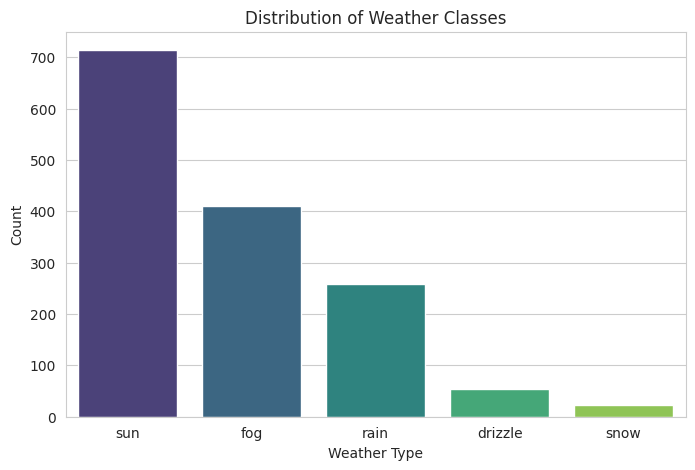

weather
sun        714
fog        411
rain       259
drizzle     54
snow        23
Name: count, dtype: int64


In [6]:
# Distribution of target classes
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='weather', palette='viridis',
              order=df['weather'].value_counts().index)
plt.title('Distribution of Weather Classes')
plt.xlabel('Weather Type')
plt.ylabel('Count')
plt.show()

print(df['weather'].value_counts())

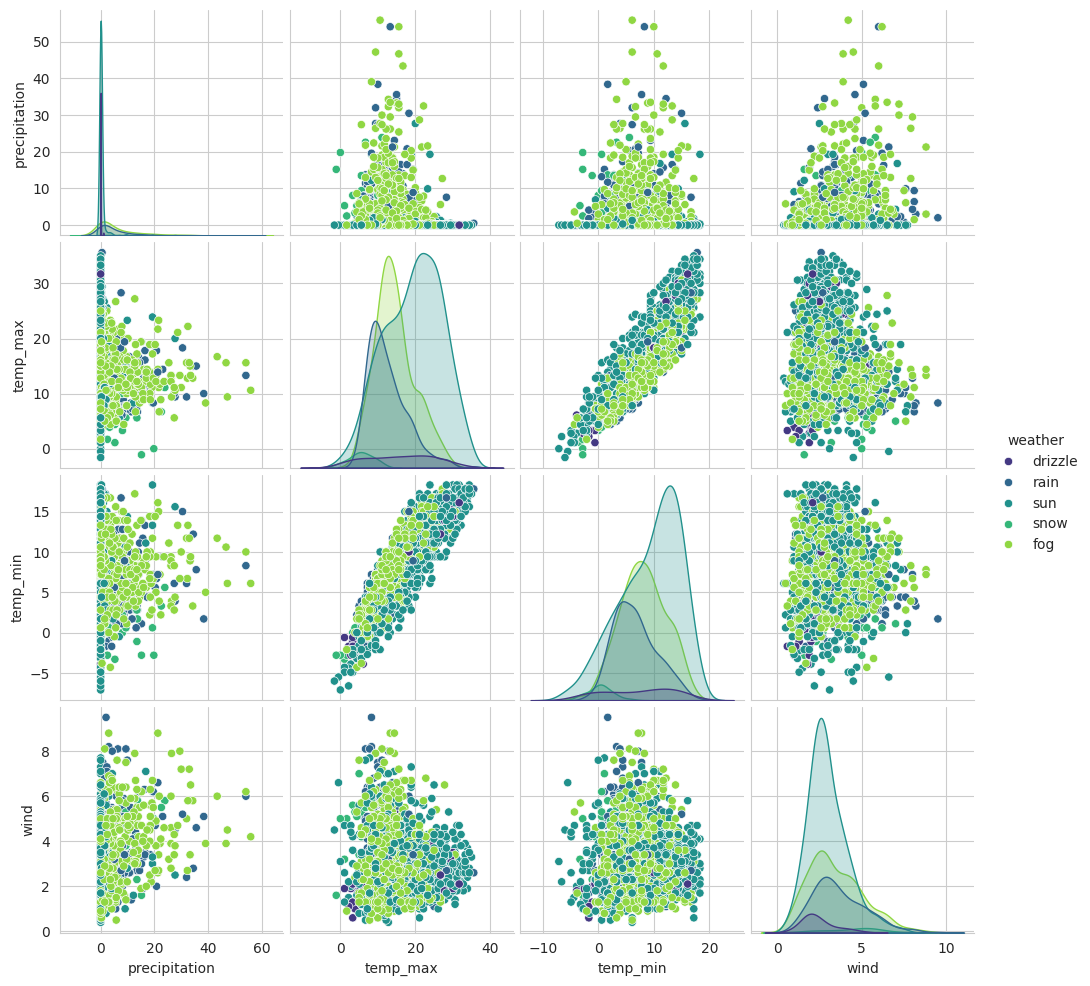

In [7]:
# Pairplot - visualize relationships between numeric features colored by weather
sns.pairplot(df.drop(columns=['date']), hue='weather', palette='viridis')
plt.show()

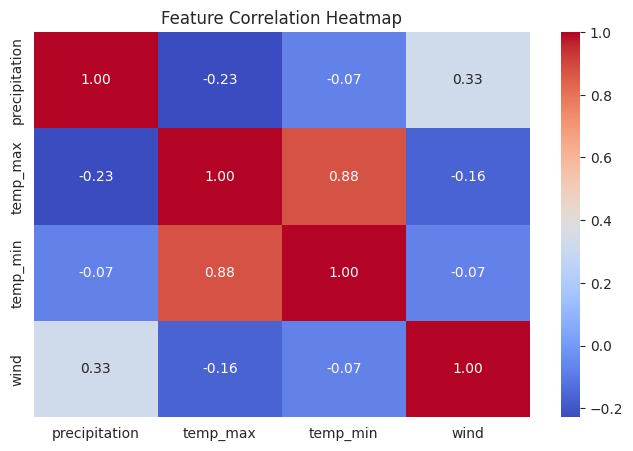

In [8]:
# Correlation heatmap of numeric features
plt.figure(figsize=(8, 5))
sns.heatmap(df.drop(columns=['date', 'weather']).corr(),
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

## 4. Data Preprocessing
- Drop the `date` column (not useful for classification).
- Encode the target `weather` (string) into numbers using `LabelEncoder`.
- Split into train/test (80% / 20%).
- Standardize features (needed for KNN and SVM).

In [9]:
# Drop date column
df = df.drop(columns=['date'])

# Encode the target column
le = LabelEncoder()
df['weather'] = le.fit_transform(df['weather'])

class_names = list(le.classes_)
print('Encoded classes:', dict(zip(range(len(class_names)), class_names)))

Encoded classes: {0: 'drizzle', 1: 'fog', 2: 'rain', 3: 'snow', 4: 'sun'}


In [10]:
# Features and target
X = df.drop(columns=['weather'])
y = df['weather']

# Train / Test split (stratified to keep class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print('Train size:', X_train.shape, '| Test size:', X_test.shape)

Train size: (1168, 4) | Test size: (293, 4)


In [11]:
# Standardize features (used for KNN and SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

## 5. Helper Function for Evaluation
Each model will be evaluated with the same metrics so they can be compared fairly.

In [12]:
results = {}

def evaluate_model(name, y_true, y_pred):
    """Compute metrics, plot confusion matrix, and store results."""
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted')
    f1   = f1_score(y_true, y_pred, average='weighted')

    results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-score': f1}

    print(f'=== {name} ===')
    print(f'Accuracy : {acc:.4f}')
    print(f'Precision: {prec:.4f}')
    print(f'Recall   : {rec:.4f}')
    print(f'F1-score : {f1:.4f}\n')
    print('Classification Report:')
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

## 6. Model 1 — Random Forest

=== Random Forest ===
Accuracy : 0.6587
Precision: 0.6376
Recall   : 0.6587
F1-score : 0.6428

Classification Report:
              precision    recall  f1-score   support

     drizzle       0.17      0.09      0.12        11
         fog       0.57      0.63      0.60        82
        rain       0.48      0.31      0.38        52
        snow       0.50      0.60      0.55         5
         sun       0.78      0.85      0.81       143

    accuracy                           0.66       293
   macro avg       0.50      0.50      0.49       293
weighted avg       0.64      0.66      0.64       293



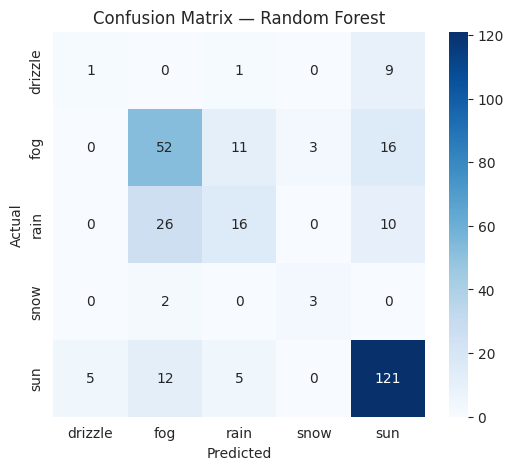

In [13]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
evaluate_model('Random Forest', y_test, rf_pred)

## 7. Model 2 — K-Nearest Neighbors (KNN)
Uses scaled features (KNN is distance-based).

=== KNN ===
Accuracy : 0.6382
Precision: 0.6083
Recall   : 0.6382
F1-score : 0.6161

Classification Report:
              precision    recall  f1-score   support

     drizzle       0.33      0.09      0.14        11
         fog       0.56      0.65      0.60        82
        rain       0.46      0.31      0.37        52
        snow       0.00      0.00      0.00         5
         sun       0.73      0.82      0.77       143

    accuracy                           0.64       293
   macro avg       0.42      0.37      0.38       293
weighted avg       0.61      0.64      0.62       293



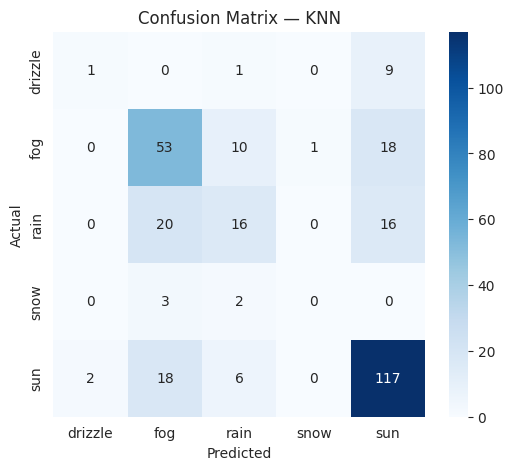

In [14]:
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_scaled, y_train)
knn_pred = knn.predict(X_test_scaled)
evaluate_model('KNN', y_test, knn_pred)

## 8. Model 3 — Support Vector Machine (SVM)
Uses scaled features with an RBF kernel.

=== SVM ===
Accuracy : 0.6553
Precision: 0.6134
Recall   : 0.6553
F1-score : 0.6101

Classification Report:
              precision    recall  f1-score   support

     drizzle       0.00      0.00      0.00        11
         fog       0.63      0.50      0.56        82
        rain       0.48      0.25      0.33        52
        snow       1.00      0.20      0.33         5
         sun       0.69      0.96      0.80       143

    accuracy                           0.66       293
   macro avg       0.56      0.38      0.40       293
weighted avg       0.61      0.66      0.61       293



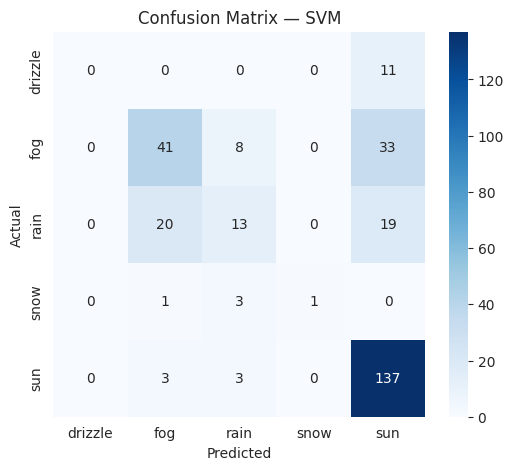

In [15]:
svm = SVC(kernel='rbf', C=1.0, random_state=42)
svm.fit(X_train_scaled, y_train)
svm_pred = svm.predict(X_test_scaled)
evaluate_model('SVM', y_test, svm_pred)

## 9. Model 4 — XGBoost

=== XGBoost ===
Accuracy : 0.6860
Precision: 0.6595
Recall   : 0.6860
F1-score : 0.6636

Classification Report:
              precision    recall  f1-score   support

     drizzle       0.25      0.09      0.13        11
         fog       0.60      0.61      0.60        82
        rain       0.55      0.33      0.41        52
        snow       0.50      0.60      0.55         5
         sun       0.77      0.91      0.84       143

    accuracy                           0.69       293
   macro avg       0.53      0.51      0.51       293
weighted avg       0.66      0.69      0.66       293



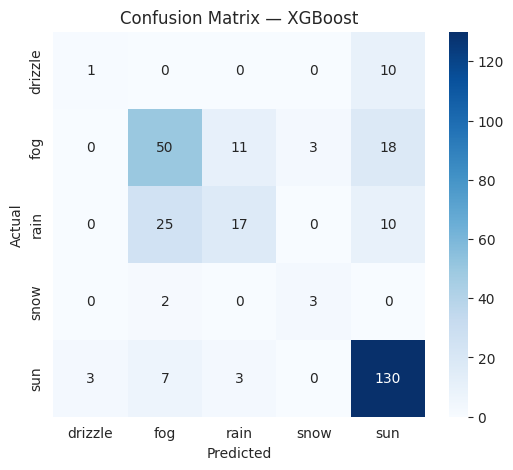

In [16]:
xgb_model = XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.1,
    use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
evaluate_model('XGBoost', y_test, xgb_pred)

## 10. Comparing the Models

In [17]:
results_df = pd.DataFrame(results).T
results_df = results_df.round(4)
results_df

,Accuracy,Precision,Recall,F1-score
Random Forest,0.6587,0.6376,0.6587,0.6428
KNN,0.6382,0.6083,0.6382,0.6161
SVM,0.6553,0.6134,0.6553,0.6101
XGBoost,0.6860,0.6595,0.6860,0.6636


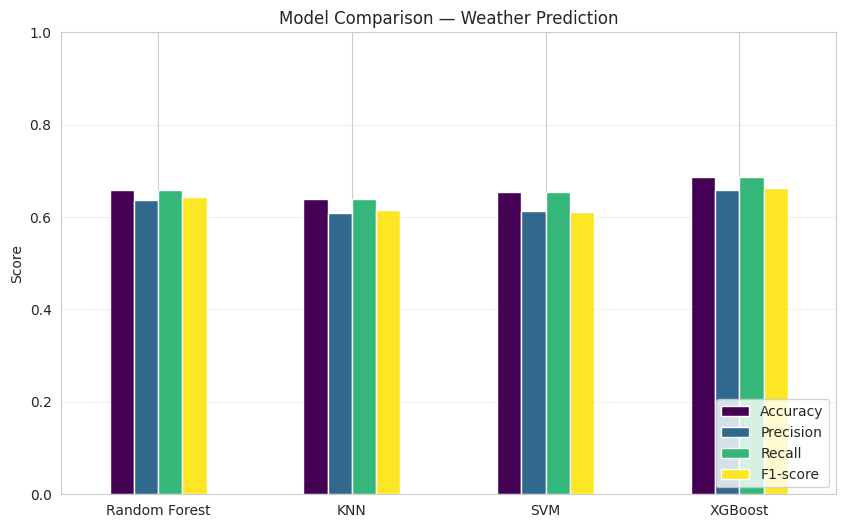

In [18]:
# Bar chart comparison
results_df.plot(kind='bar', figsize=(10, 6), colormap='viridis')
plt.title('Model Comparison — Weather Prediction')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [19]:
best_model = results_df['F1-score'].idxmax()
print(f'Best performing model (by F1-score): {best_model}')
print(results_df.loc[best_model])

Best performing model (by F1-score): XGBoost
Accuracy     0.6860
Precision    0.6595
Recall       0.6860
F1-score     0.6636
Name: XGBoost, dtype: float64


## 11. Conclusion

Four classification algorithms were trained and compared on the Seattle Weather dataset to predict daily weather conditions:

- **Random Forest** and **XGBoost** are tree-based ensemble methods that work directly with raw feature values.
- **KNN** and **SVM** are distance/margin-based methods that benefit from feature scaling.

All models achieve comparable accuracy on this 5-class problem. The dataset is imbalanced (sunny days dominate), which limits performance on minority classes such as `snow` and `drizzle` — visible in the confusion matrices.

Possible improvements:
- Hyperparameter tuning (`GridSearchCV`).
- Handling class imbalance (SMOTE / class weighting).
- Feature engineering (e.g. month / season from the date).